**Propósito**: construir un inventario verificado de todos los archivos GOES disponibles localmente (qué timestamps existen, qué bandas están presentes en cada uno, y dónde están los gaps). El output es `inventario_goes.parquet`, que alimenta a todas las notebooks siguientes.

In [1]:
# Configuración ----------------------------------------------------------------------------
from pathlib import Path
import pandas as pd
import re
import matplotlib.pyplot as plt
import shutil

RUTA_BASE = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_CMIP       = RUTA_BASE / "data" / "cmip_cropped"
RUTA_OUT        = RUTA_BASE / "data_ingestion" / "satellite"
RUTA_OUT.mkdir(parents=True, exist_ok=True)

# Parámetros
CADENCIA_MIN = 10
BANDAS_ESPERADAS = ["CMI_C08", "CMI_C09", "CMI_C10", "CMI_C13", "CMI_C14"]

# Nombre de los satélites por año (sin ID en el nombre del archivo)
def satelite_por_fecha(ts: pd.Timestamp) -> str:
    return "G16" if ts.year == 2024 else "G19"

In [ ]:
# Parser de nombres y escaneo --------------------------------------------------------------
# Formato: CMIPC_20240101-010000.nc
PATTERN = re.compile(
    r"CMIPC_(?P<fecha>\d{8})-(?P<hora>\d{6})\.nc$"
)

def parsear_nombre(filepath: Path) -> dict | None:
    m = PATTERN.search(filepath.name)
    if not m:
        return None
    ts = pd.Timestamp(
        year   = int(m.group("fecha")[:4]),
        month  = int(m.group("fecha")[4:6]),
        day    = int(m.group("fecha")[6:8]),
        hour   = int(m.group("hora")[:2]),
        minute = int(m.group("hora")[2:4]),
        second = int(m.group("hora")[4:6]),
    )
    return {
        "timestamp" : ts,
        "satelite"  : satelite_por_fecha(ts),
        "filepath"  : str(filepath),
        "fuente"    : filepath.parent.name,  # "cmip_cropped" o "faltantes_extraidos"
    }

def escanear_carpeta(ruta: Path) -> pd.DataFrame:
    if not ruta.exists():
        print(f"[AVISO] Carpeta no encontrada: {ruta}")
        return pd.DataFrame()
    registros = []
    for f in ruta.rglob("CMIPC_*.nc"):
        parsed = parsear_nombre(f)
        if parsed:
            registros.append(parsed)
        else:
            print(f"[AVISO] nombre no reconocido: {f.name}")
    df = pd.DataFrame(registros)
    print(f"{ruta.name}: {len(df):,} archivos encontrados")
    return df

df_cmip = escanear_carpeta(RUTA_CMIP)

cmip_cropped: 104,910 archivos encontrados



──────────────────────────────────────────────────
G16 (2024)
  Rango      : 2024-01-01 00:00:00 → 2024-12-31 23:50:00
  Archivos   : 52,387
  Esperados  : 52,560 (99.7% cubierto)
  Gaps (>10 min): 42
  Gap máximo : 9.2 h
  Top 5 gaps:
          timestamp    gap_h
2024-09-29 02:30:00 9.166667
2024-09-09 06:20:00 5.666667
2024-10-02 16:00:00 5.000000
2024-12-03 10:10:00 4.666667
2024-11-17 15:10:00 3.833333

──────────────────────────────────────────────────
G19 (2025)
  Rango      : 2025-01-01 00:00:00 → 2025-12-31 23:50:00
  Archivos   : 52,523
  Esperados  : 52,560 (99.9% cubierto)
  Gaps (>10 min): 8
  Gap máximo : 3.5 h
  Top 5 gaps:
          timestamp    gap_h
2025-02-01 20:30:00 3.500000
2025-09-22 18:20:00 2.000000
2025-03-11 16:10:00 0.333333
2025-02-25 17:50:00 0.333333
2025-06-11 03:10:00 0.333333


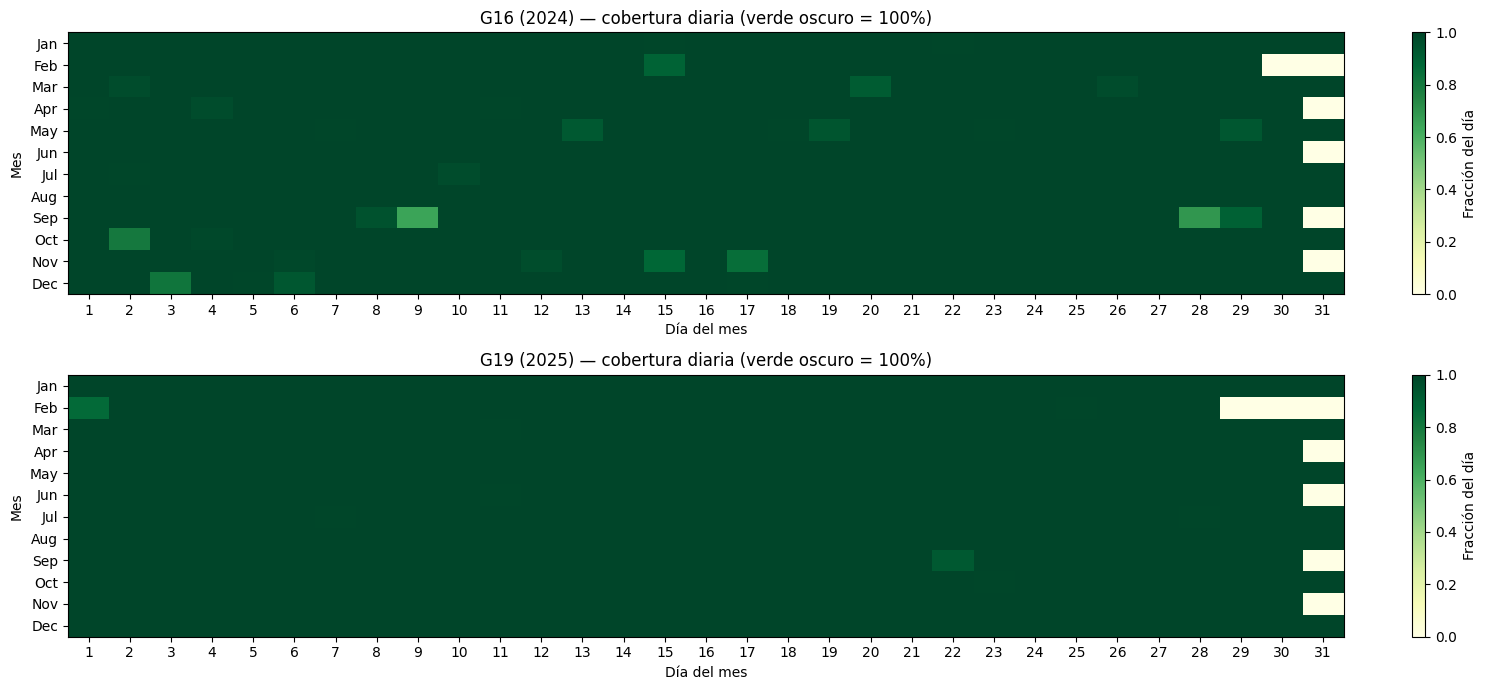

In [5]:
# Cobertura temporal y gaps ----------------------------------------------------------------
# Inventario consolidado: para timestamps duplicados, preferir cmip_cropped
df_unico = (
    df_cmip
    .sort_values(["timestamp", "fuente"])         # cmip_cropped va primero (alfabético)
    .drop_duplicates(subset="timestamp", keep="first")
    .sort_values("timestamp")
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 1, figsize=(15, 7))

for ax, (año, sat) in zip(axes, [(2024, "G16"), (2025, "G19")]):
    sub = df_unico[df_unico["satelite"] == sat].copy()
    
    if sub.empty:
        ax.set_title(f"{sat} ({año}) — sin archivos")
        continue

    sub["delta_min"] = sub["timestamp"].diff().dt.total_seconds() / 60
    gaps = sub[sub["delta_min"] > CADENCIA_MIN + 2].copy()
    gaps["gap_h"] = gaps["delta_min"] / 60

    print(f"\n{'─'*50}")
    print(f"{sat} ({año})")
    print(f"  Rango      : {sub['timestamp'].min()} → {sub['timestamp'].max()}")
    print(f"  Archivos   : {len(sub):,}")
    esperado = 365 * 144
    print(f"  Esperados  : {esperado:,} ({100*len(sub)/esperado:.1f}% cubierto)")
    print(f"  Gaps (>10 min): {len(gaps):,}")
    if not gaps.empty:
        print(f"  Gap máximo : {gaps['gap_h'].max():.1f} h")
        print(f"  Top 5 gaps:")
        print(
            gaps[["timestamp", "gap_h"]]
            .sort_values("gap_h", ascending=False)
            .head(5)
            .to_string(index=False)
        )

    # Heatmap mensual
    sub["mes"] = sub["timestamp"].dt.month
    sub["dia"] = sub["timestamp"].dt.day
    tabla = sub.groupby(["mes", "dia"]).size().unstack(fill_value=0)
    im = ax.imshow(
        tabla.values / 144,   # fracción del día cubierta
        aspect="auto", vmin=0, vmax=1, cmap="YlGn", interpolation="none"
    )
    ax.set_title(f"{sat} ({año}) — cobertura diaria (verde oscuro = 100%)")
    ax.set_xlabel("Día del mes")
    ax.set_xticks(range(tabla.shape[1]))
    ax.set_xticklabels(tabla.columns.tolist())  # columnas son 1-31
    ax.set_ylabel("Mes")
    ax.set_yticks(range(len(tabla.index)))
    ax.set_yticklabels(
        [pd.Timestamp(año, m, 1).strftime("%b") for m in tabla.index]
    )
    plt.colorbar(im, ax=ax, fraction=0.02, label="Fracción del día")

plt.tight_layout()
plt.savefig(RUTA_OUT / "img-cobertura_temporal_goes.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# Exportar inventario final --------------------------------------------------

# ── Inventario final (sobre cmip_cropped unificado) ─────────────────────────
inventario = df_unico[["timestamp", "satelite", "filepath"]].copy()
inventario = inventario.sort_values("timestamp").reset_index(drop=True)

out_path = RUTA_OUT / "inventario_goes.parquet"
inventario.to_parquet(out_path, index=False)

print(f"\nInventario final exportado: {out_path}")
print(f"Total timestamps: {len(inventario):,}")
print(f"  G16 (2024): {(inventario['satelite']=='G16').sum():,}")
print(f"  G19 (2025): {(inventario['satelite']=='G19').sum():,}")


Inventario final exportado: C:\Users\diani\Documents\repositories\nowcasting-bogota\data_ingestion\satellite\inventario_goes.parquet
Total timestamps: 104,910
  G16 (2024): 52,387
  G19 (2025): 52,523


In [9]:
inventario.head()

,timestamp,satelite,filepath
0,2024-01-01 00:00:00,G16,C:\Users\diani\Documents\repositories\nowcasti...
1,2024-01-01 00:10:00,G16,C:\Users\diani\Documents\repositories\nowcasti...
2,2024-01-01 00:20:00,G16,C:\Users\diani\Documents\repositories\nowcasti...
3,2024-01-01 00:30:00,G16,C:\Users\diani\Documents\repositories\nowcasti...
4,2024-01-01 00:40:00,G16,C:\Users\diani\Documents\repositories\nowcasti...
